In [49]:
# --- IMPORT STATEMENTS ---

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS

from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd

from photutils.detection import DAOStarFinder

In [50]:
# --- GLOBAL VARIABLES ---

# LINUX_DIRECTORY = "/home/aimee/mphys" # Aimee
LINUX_DIRECTORY = "/home/u20482jg/MPHYS_Project_Local/" # Joe
FIGURE_SAVEDIR = f"figures/masking"
CSV_SAVEDIR = f'{LINUX_DIRECTORY}/data'
SAVE_FIGS = True

FWHM_PS = 5 # arcmin
THRESHOLD_FACTOR = 0.3

L_BOUNDS = [16, 32] # degrees
B_BOUNDS = [-1.1, 1.1] # degrees

GDIGS_MAPS_DIR = f"{LINUX_DIRECTORY}/data/GDIGS_moment0"
GDIGS_MAPS = {
    "GDIGS G017.50":"GDIGS_G017.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G022.50":"GDIGS_G022.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G027.25":"GDIGS_G027.25+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G030.80":"GDIGS_G030.80+00.00_halpha_2pol_average_moment0.fits"
               }
GDIGS_KEYS = list(GDIGS_MAPS.keys())

In [51]:
# --- FUNCTION DEFINITIONS ---

In [52]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS): # modified from jg_notebooks/gp_plotting.ipynb
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = -0.01 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [K]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if SAVE_FIGS:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [53]:
def GDIGS_mosaic(): # modified from jg_notebooks/gp_plotting.ipynb

    paths = []
    for key in GDIGS_KEYS:
        paths.append(f"{GDIGS_MAPS_DIR}/{GDIGS_MAPS[key]}")

    GDIGS_rawfits = [fits.open(path)[0] for path in paths]

    mosaics = [(rawfit.data, rawfit.header) for rawfit in GDIGS_rawfits]

    mosaic_WCS, shape = find_optimal_celestial_wcs(mosaics)

    mosaic, _mosaic_ftprint = reproject_and_coadd(
        mosaics,
        output_projection = mosaic_WCS,
        shape_out = shape,
        reproject_function = reproject_interp,
        combine_function = "mean"
        )

    # prevents area outside mosaic from being plotted
    mosaic[mosaic == 0.0] = hp.UNSEEN
    # print(paths)

    return mosaic, mosaic_WCS

In [54]:

def find_point_sources(fits_data):
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # DAOStarFinder doesn't like hp.UNSEEN

    # Calculate std of whole image
    std = np.nanstd(fits_data) # nanstd ignores nans
    # print(f'STANDARD DEVIAION  = {std}')

    daofind =  DAOStarFinder(fwhm=FWHM_PS, threshold = THRESHOLD_FACTOR*std) # TWEAK
    sources = daofind(fits_data)

    if sources:
        print(f'\nNumber of point sources identified: {len(sources)}')
        # print(sources)
        x_coords = sources['xcentroid']
        y_coords = sources['ycentroid']
    else:
        print('No point sources identified')
        x_coords = []
        y_coords = []

    return x_coords, y_coords     

In [55]:
def create_point_source_mask(fits_data, x_coords, y_coords, fwhm, show_mask=False):

    # Calculate sigma from FWHM
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))

    # Create meshgrid corresponding to image coords
    y, x = np.indices(fits_data.shape)

    # Create mask
    mask = np.zeros(fits_data.shape, dtype=bool) # empty, same shape as GDIGS mosaic
    for x_c, y_c in zip(x_coords, y_coords):
        distance = np.sqrt((x - x_c)**2 + (y - y_c)**2) 
        mask = np.logical_or(mask, distance < 3*sigma)  # if pixel is < 3*sigma away from centre of point source (i.e. inside Gaussian), mask it

    if show_mask: # quick plot, can expand to convert coords, add axis labels, etc. if necessary
        plt.imshow(mask, origin='lower', cmap='gray')
        plt.title('Point Source Mask')
        plt.show()
    
    return mask

In [56]:
def write_to_csv(x_coords, y_coords, radius=FWHM_PS, file_name='data.csv'):
    
    file_path = f'{CSV_SAVEDIR}/{file_name}'
    header = "l [deg], b [deg], Radius [arcmin]"

    radius_arr = np.full_like(x_coords, radius)
    data_arr = np.array([x_coords, y_coords, radius_arr]).T

    np.savetxt(file_path, data_arr, delimiter = ",", header=header)

    print(f'File saved as {file_path}')


In [57]:
def pixel_to_galactic(x_coords, y_coords, WCS):

    l_coords = []
    b_coords = []
    for i, _ in enumerate(x_coords):
        x = x_coords[i] 
        y = y_coords[i]
        l, b = WCS.all_pix2world(float(x), float(y), 0)

        l_coords.append(l)
        b_coords.append(b)
    
    return l_coords, b_coords

In [58]:
def main():
    show_plots = True

    mosaic, mosaic_WCS = GDIGS_mosaic()
    plot_fits(mosaic, mosaic_WCS, title='GDIGS Moment 0')
    
    x_ps, y_ps = find_point_sources(mosaic)
    
    if show_plots:
        plot_fits(mosaic, mosaic_WCS, x_coords=x_ps, y_coords=y_ps, title='GDIGS Moment 0 - Point Sources Locations')
    mask_ps = create_point_source_mask(mosaic, x_ps, y_ps, fwhm=FWHM_PS, show_mask=show_plots)
    if show_plots:
        mosaic_ps = mosaic.copy()
        mosaic_ps[mask_ps] = hp.UNSEEN
        plot_fits(mosaic_ps, mosaic_WCS, title='GDIGS Moment 0 - Point Sources Masked')
    
    l_ps, b_ps = pixel_to_galactic(x_ps, y_ps, mosaic_WCS)
    write_to_csv(l_ps, b_ps, file_name='point_sources_final.csv')

In [59]:
# --- MAIN CODE ---
# main()

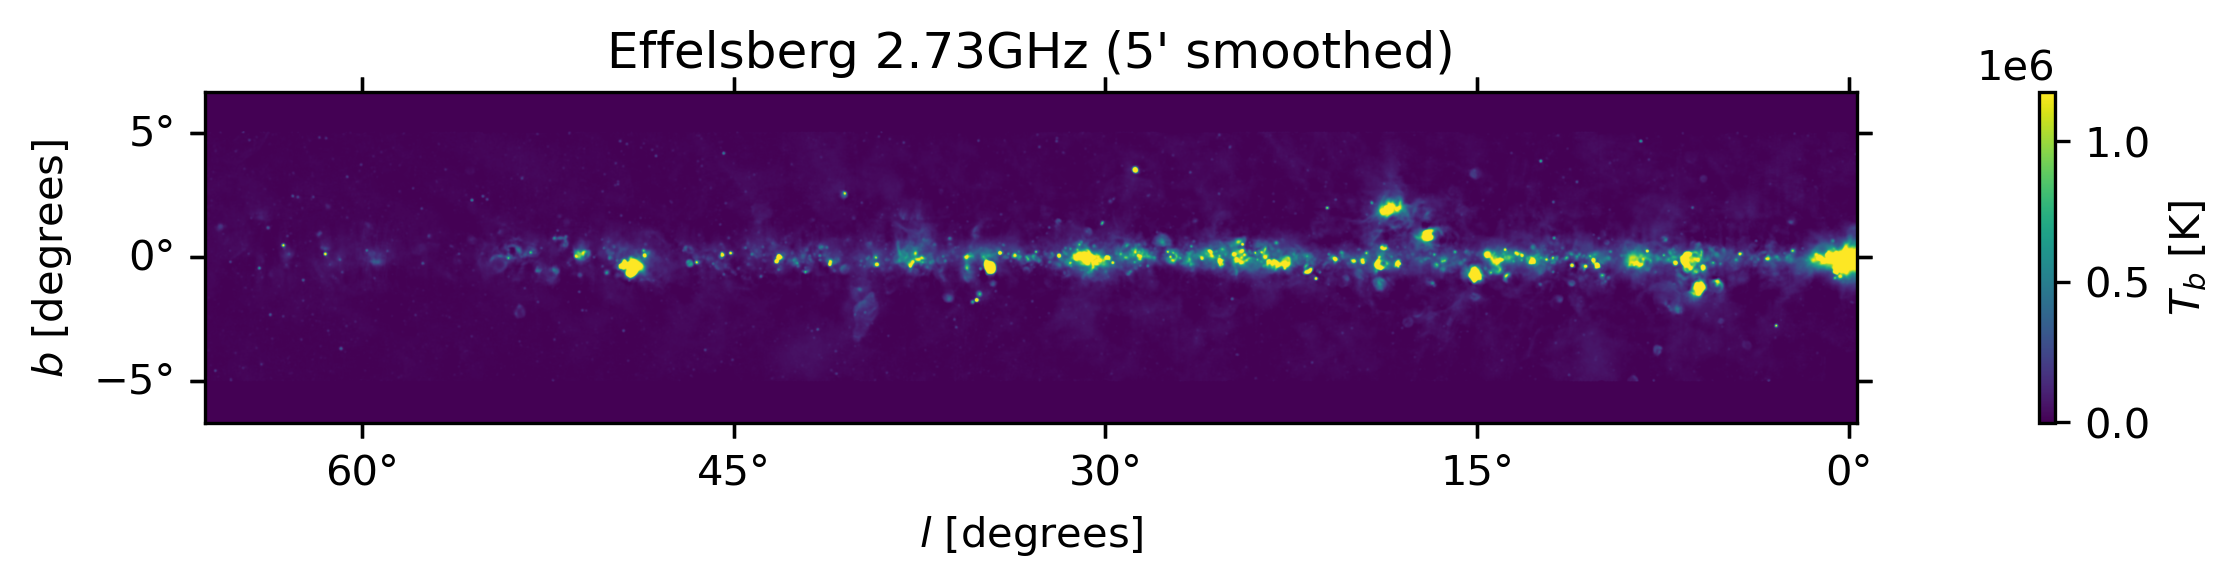


Number of point sources identified: 123


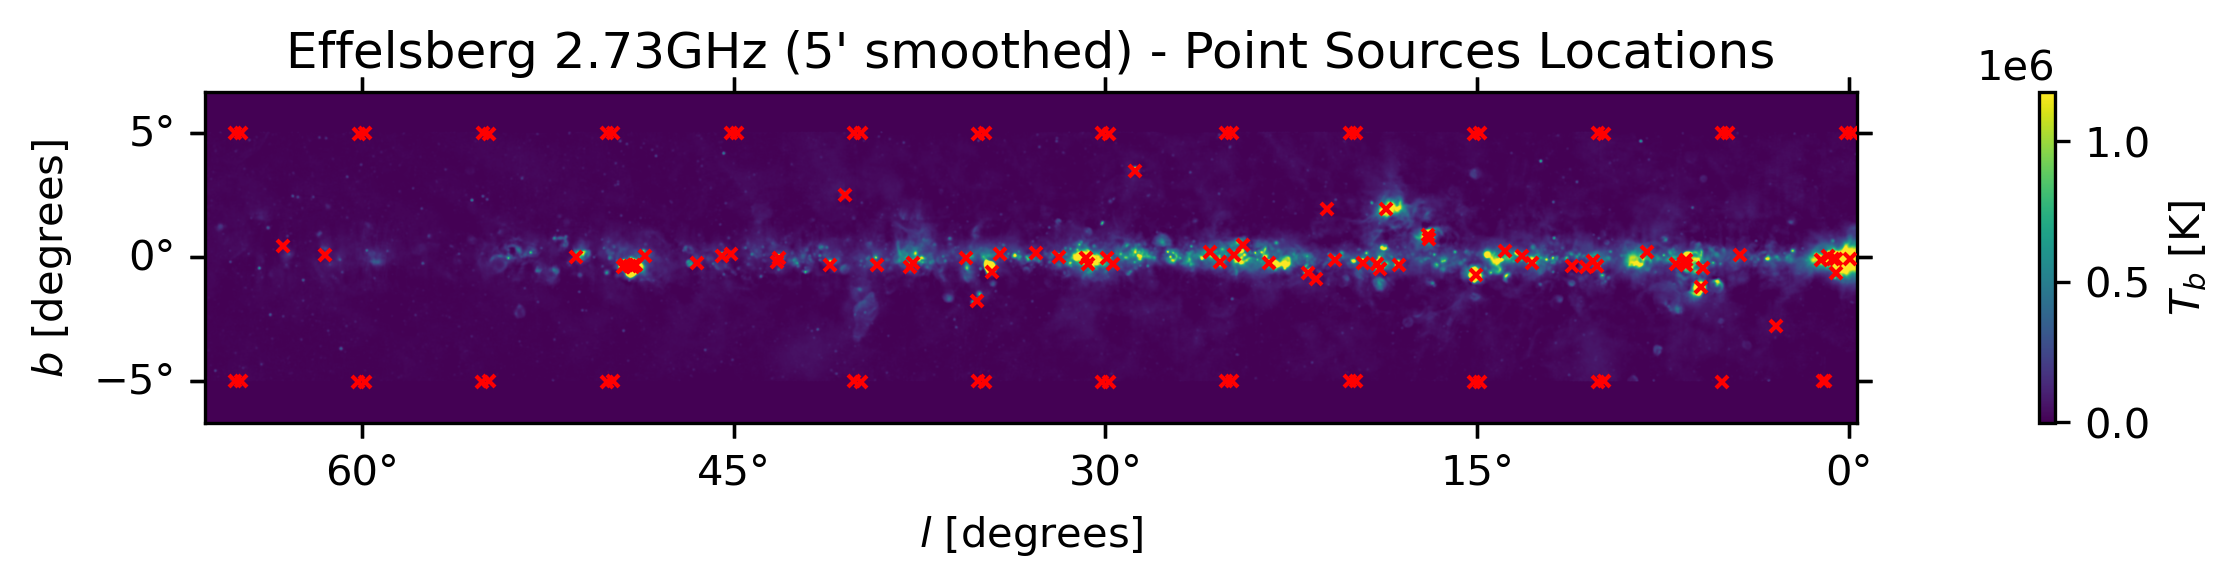

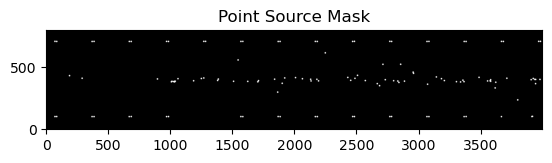

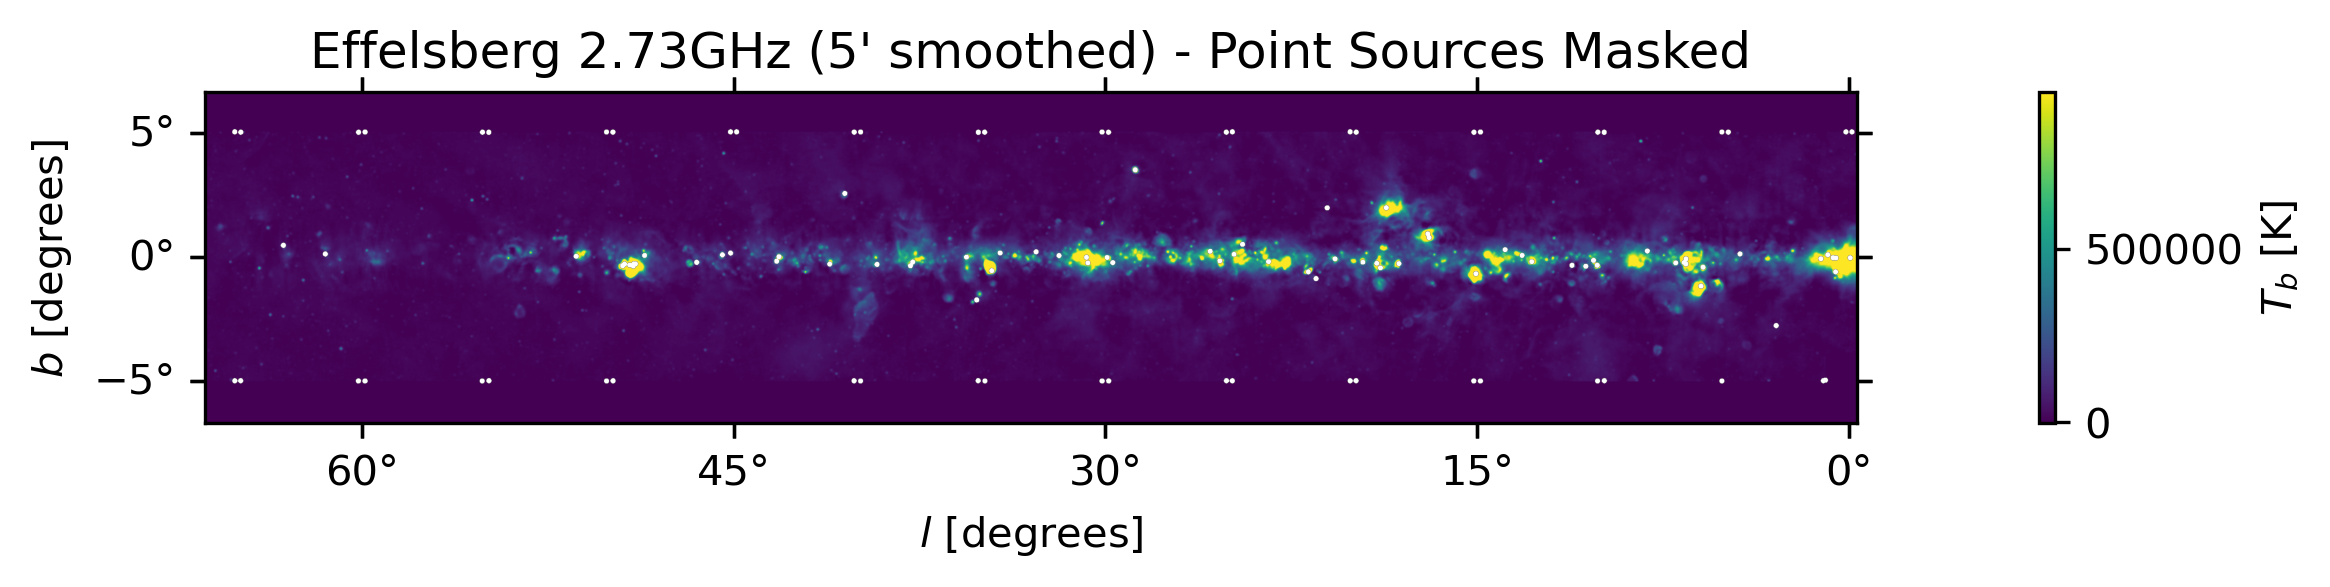

File saved as /home/u20482jg/MPHYS_Project_Local//data/Effelsberg_2.73GHz_(5'_smoothed)_point_sources_final.csv


In [60]:
# Added by Joe - I'll let you double check this before running it but I believe this should work for finding point sources in other maps (hopefully at least effelsberg)
MAP_PATH = f"{LINUX_DIRECTORY}/data/all_maps/maps/EFFELSBERG-2.7272727272727275GHz-5.0amin.fits"


def get_map(path):
    
    # print(f"\nGetting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    wcs = WCS(header)
        
    return data, header, wcs


def maingen(data, wcs, map_title='Map'):
    show_plots = True
    maptitle_fileout = '_'.join(map_title.split(' '))

    plot_fits(data, wcs, title = map_title)
    
    x_ps, y_ps = find_point_sources(data)
    
    if show_plots:
        plot_fits(data, wcs, x_coords=x_ps, y_coords=y_ps, title=f'{map_title} - Point Sources Locations')
    mask_ps = create_point_source_mask(data, x_ps, y_ps, fwhm=FWHM_PS, show_mask=show_plots)
    if show_plots:
        data_ps = data.copy()
        data_ps[mask_ps] = hp.UNSEEN
        plot_fits(data_ps, wcs, title=f'{map_title} - Point Sources Masked')
    
    l_ps, b_ps = pixel_to_galactic(x_ps, y_ps, wcs)
    write_to_csv(l_ps, b_ps, file_name=f'{maptitle_fileout}_point_sources_final.csv')


map_data, _, map_wcs = get_map(MAP_PATH)

maingen(map_data, map_wcs, map_title = "Effelsberg 2.73GHz (5' smoothed)")
